In [1]:
# Step 0: import libraries and connect google drive

from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

drive.mount('/content/drive')

# load dataset
df = pd.read_csv('diabetic_data.csv')

# quick check
print("dataset shape:", df.shape)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
dataset shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [2]:
# Step 1: Understand dataset structure

# column types and missing values overview
df.info()

# summary statistics for numeric columns
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


weight               0.968585
max_glu_serum        0.947468
A1Cresult            0.832773
medical_specialty    0.490822
payer_code           0.395574
race                 0.022336
diag_3               0.013983
diag_2               0.003518
diag_1               0.000206
patient_nbr          0.000000
dtype: float64


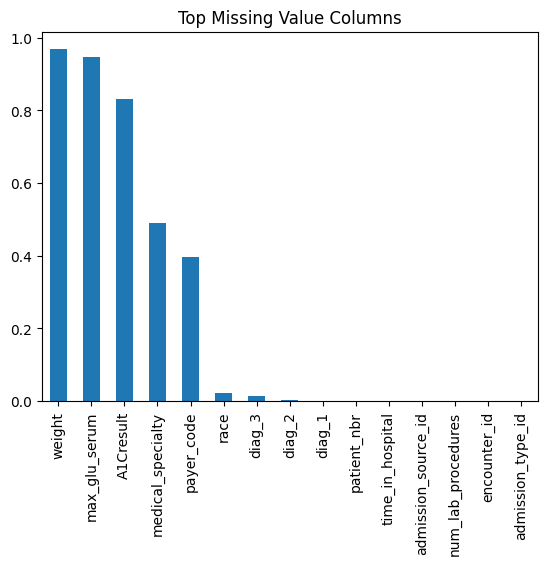

In [3]:
# Step 2: Missing values overview

# replace ? with nan for analysis
df = df.replace("?", np.nan)

missing = df.isnull().mean().sort_values(ascending=False)

print(missing.head(10))

plt.figure()
missing.head(15).plot(kind="bar")
plt.title("Top Missing Value Columns")
plt.show()

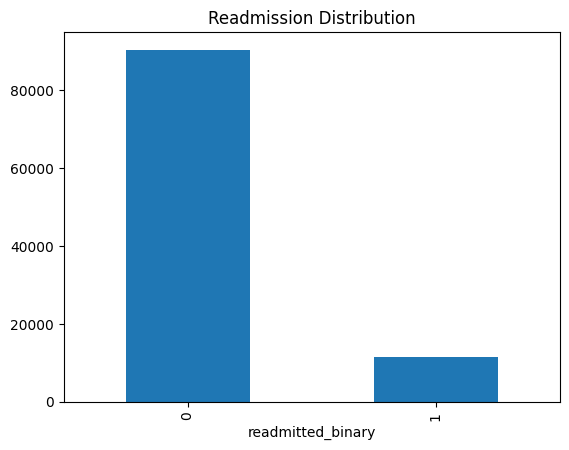

In [4]:
# Step 3: Analyze target distribution

df["readmitted_binary"] = df["readmitted"].apply(
    lambda x: 1 if x == "<30" else 0
)

df["readmitted_binary"].value_counts(normalize=True)

plt.figure()
df["readmitted_binary"].value_counts().plot(kind="bar")
plt.title("Readmission Distribution")
plt.show()

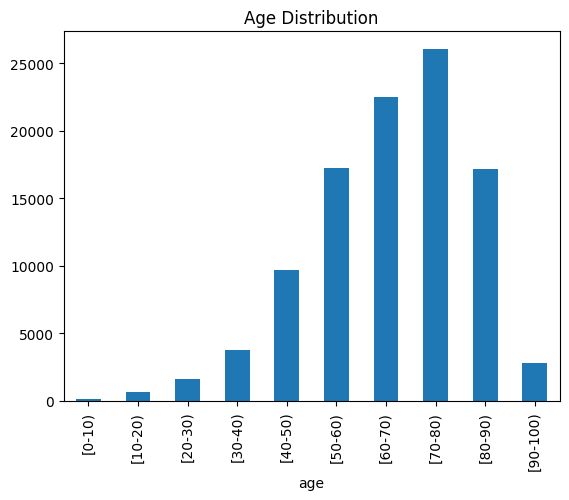

In [5]:
# Step 4: Age distribution analysis

plt.figure()
df["age"].value_counts().sort_index().plot(kind="bar")
plt.title("Age Distribution")
plt.show()

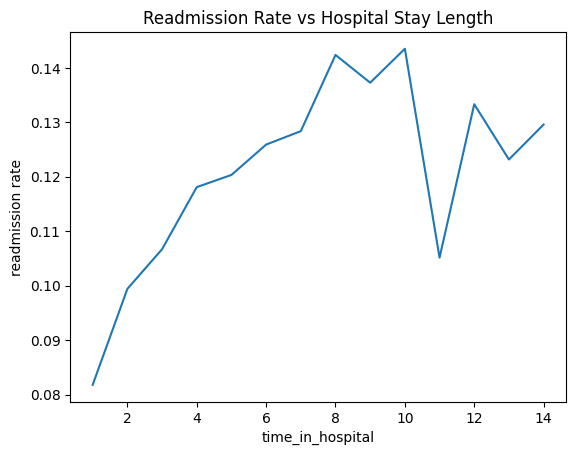

In [6]:
# Step 5: Relationship between time in hospital and readmission

plt.figure()
df.groupby("time_in_hospital")["readmitted_binary"].mean().plot()
plt.title("Readmission Rate vs Hospital Stay Length")
plt.ylabel("readmission rate")
plt.show()

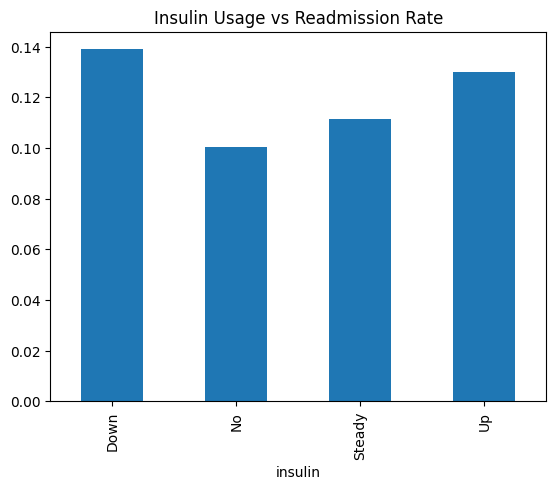

In [7]:
# Step 6: Insulin usage vs readmission

plt.figure()
df.groupby("insulin")["readmitted_binary"].mean().plot(kind="bar")
plt.title("Insulin Usage vs Readmission Rate")
plt.show()

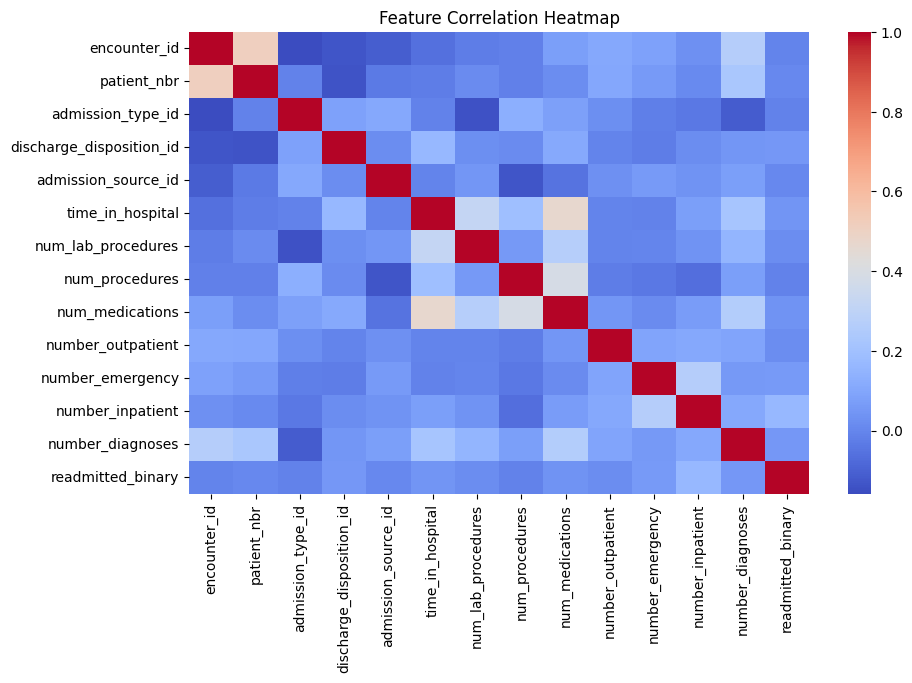

In [8]:
# Step 7: Correlation heatmap for numeric features

numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

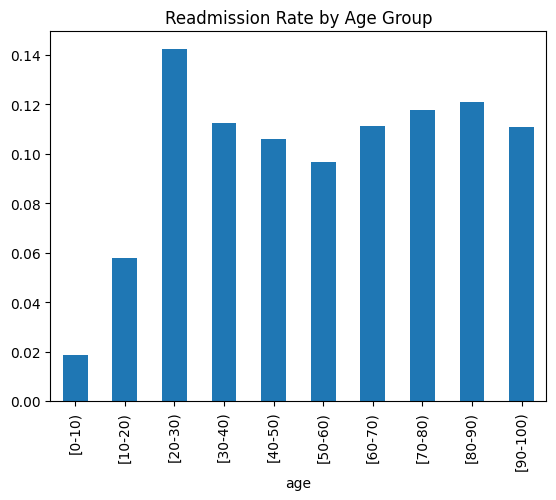

In [9]:
# Step 8: Age vs Readmission

df.groupby("age")["readmitted_binary"].mean().plot(kind="bar")
plt.title("Readmission Rate by Age Group")
plt.show()

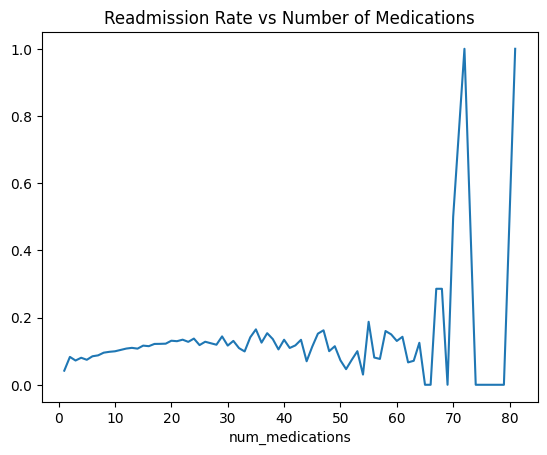

In [10]:
# Step 9: Number of Medications vs Readmission

df.groupby("num_medications")["readmitted_binary"].mean().plot()
plt.title("Readmission Rate vs Number of Medications")
plt.show()

## EDA Findings

The dataset contains 101,766 patient records and 50 features. Most variables are categorical, with 37 object-type columns and 13 numeric columns. This indicates that preprocessing and encoding will be necessary before any modeling can be applied.

### Target Variable Distribution

The target variable, readmission within 30 days, is highly imbalanced. Approximately 88.84 percent of patients are not readmitted within 30 days, while 11.16 percent are readmitted within 30 days. This imbalance is important because it affects model performance and evaluation metrics, especially for the minority class.

### Missing Data

Several features contain significant missing values. The most affected variables are weight, max_glu_serum, and A1Cresult, with missing rates above 80 percent in some cases. Overall, five features have missingness greater than 30 percent, which may require removal or careful handling during preprocessing.

### Age Distribution

The dataset is skewed toward older age groups. The most common age group is 70 to 80 years old, with 26,068 records. This suggests that the dataset primarily represents an older hospitalized population, which is expected in diabetes-related hospital admissions.

### Hospital Stay And Readmission

There is a gradual increase in readmission rate as hospital stay length increases. Patients with shorter stays have lower readmission rates, while those with longer stays show higher readmission probabilities. The highest observed readmission rate occurs at 10 days of hospital stay, at approximately 14.35 percent.

### Medication And Insulin Effects

Patients with different insulin treatments show varying readmission rates. The highest readmission rate appears in the "Down" insulin category, followed by "Up" and "Steady" categories, with "No" insulin having the lowest rate.

Similarly, medication count is related to readmission risk. Patients with higher numbers of medications generally show increased readmission rates. However, this relationship is not strictly linear, suggesting other confounding clinical factors.

### Correlation Analysis

The strongest positive correlation with readmission is number of inpatient visits, indicating that prior hospital usage is a strong predictor of future readmission. Other variables such as emergency visits, discharge disposition, and number of diagnoses show weaker positive correlations.

Most individual features have weak linear relationships with readmission, suggesting that the problem is likely nonlinear and may benefit from more complex models than simple linear regression.

### Key Insights

1. The dataset is heavily imbalanced toward non-readmitted patients, which must be addressed during modeling.  
2. A small number of features contain most of the missing data and may require removal or imputation strategies.  
3. Older patients, longer hospital stays, higher medication counts, and insulin-related variables show noticeable variation in readmission risk.  
4. No single feature strongly determines readmission, indicating that predictive modeling will rely on combining multiple weak signals.

Overall, the dataset contains meaningful patterns, but the prediction task is complex due to class imbalance, missing data, and weak individual feature correlations.